# 📱 Customer Churn Prediction
## Business Problem
A telecom company is losing customers every month.
The goal is to predict which customers are likely to
cancel their subscription so the company can reach
out and offer retention deals before they leave.

In [ ]:
#python
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/sample_data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Drop customerID
df = df.drop('customerID', axis=1)

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

# Convert Churn
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Convert gender
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

# Convert ALL Yes/No columns INCLUDING MultipleLines
yes_no_columns = ['Partner', 'Dependents', 'PhoneService',
                  'MultipleLines',
                  'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'PaperlessBilling']

for col in yes_no_columns:
    df[col] = df[col].map({'Yes': 1, 'No': 0,
                           'No internet service': 0,
                           'No phone service': 0})

# One Hot Encoding
df = pd.get_dummies(df, columns=['InternetService',
                                  'Contract',
                                  'PaymentMethod'],
                                  drop_first=True)

# Fix True/False to 1/0
df = df.astype({col: int for col in df.select_dtypes(bool).columns})

print("✅ Cleaning done!")
print("Shape:", df.shape)
print("Text remaining:", df.select_dtypes('object').columns.tolist())
df.head()

✅ Cleaning done!
Shape: (7032, 24)
Text remaining: []


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,1,0,0,0,0,1,0


## Data Cleaning
- Removed customerID (not useful for prediction)
- Fixed TotalCharges column (had 11 blank rows)
- Converted all text columns to numbers using
  Label Encoding and One Hot Encoding
- Final dataset: 7,032 customers, 24 features

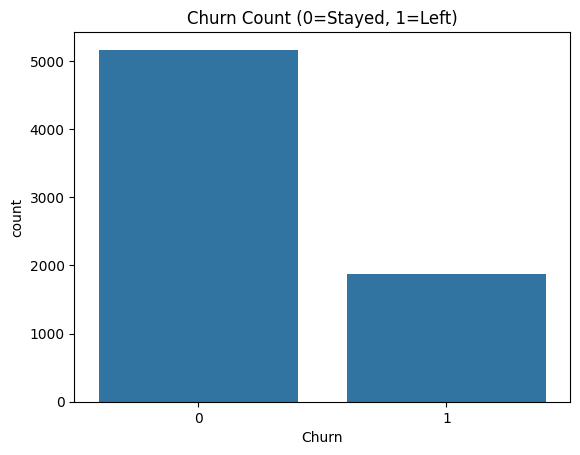

In [ ]:
# Chart 1 - Churn Count
sns.countplot(x='Churn', data=df)
plt.title('Churn Count (0=Stayed, 1=Left)')
plt.show()

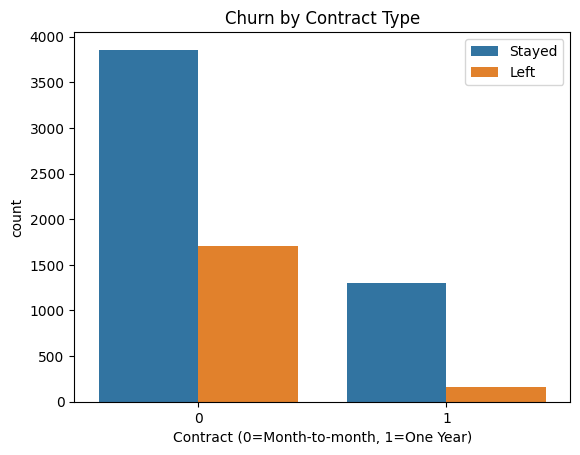

In [ ]:
# Chart 2 - Churn by Contract Type
sns.countplot(x='Contract_One year', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.xlabel('Contract (0=Month-to-month, 1=One Year)')
plt.legend(['Stayed', 'Left'])
plt.show()

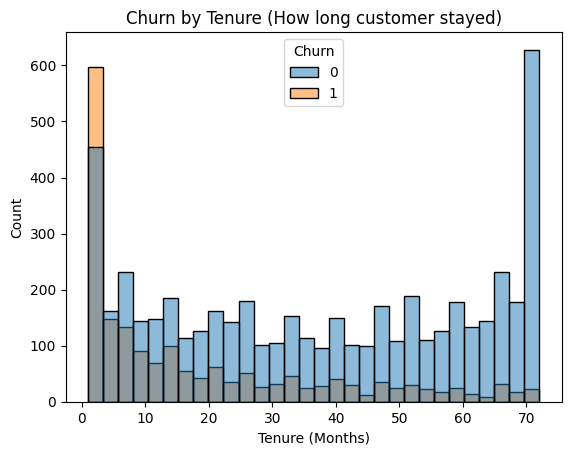

In [ ]:
# Chart 3 - Churn by Tenure
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)
plt.title('Churn by Tenure (How long customer stayed)')
plt.xlabel('Tenure (Months)')
plt.show()

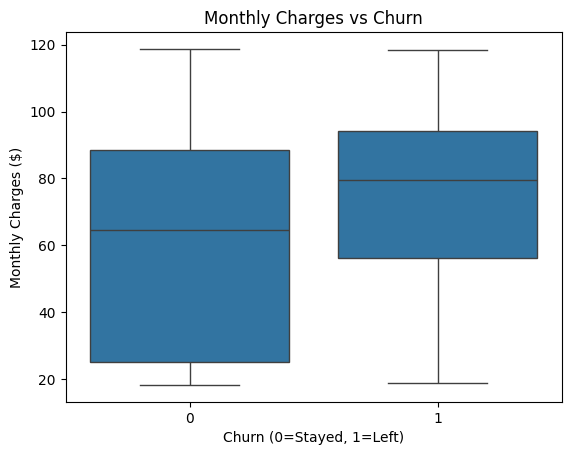

In [ ]:
# Chart 4 - Monthly Charges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn (0=Stayed, 1=Left)')
plt.ylabel('Monthly Charges ($)')
plt.show()

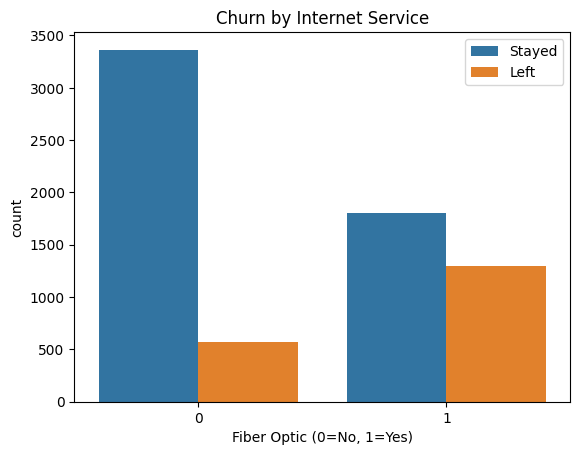

In [ ]:
# Chart 5 - Churn by Internet Service
sns.countplot(x='InternetService_Fiber optic', hue='Churn', data=df)
plt.title('Churn by Internet Service')
plt.xlabel('Fiber Optic (0=No, 1=Yes)')
plt.legend(['Stayed', 'Left'])
plt.show()

## Key Findings from Visualizations
1. 27% of customers churned (1,869 out of 7,032)
2. Month-to-month customers churn most
3. New customers (0-10 months) are highest risk
4. Customers paying above $80/month churn more
5. Fiber optic customers churn 3x more than DSL

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 23)
y shape: (7032,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (5625, 23)
Testing size: (1407, 23)


In [ ]:
!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 4130, 1: 1495}
After SMOTE: {1: 4130, 0: 4130}


## Handling Imbalanced Data
The dataset was imbalanced — 73% stayed vs 27% churned.
Used SMOTE to balance training data to 50/50.
This prevents the model from being lazy and always
predicting "No churn".

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sm = scaler.fit_transform(X_train_sm)
X_test = scaler.transform(X_test)
print("✅ Scaling done!")

✅ Scaling done!


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_sm, y_train_sm)
y_pred_lr = lr.predict(X_test)

lr_score = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", round(lr_score * 100, 2), "%")

Logistic Regression Accuracy: 76.05 %


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_sm, y_train_sm)
y_pred_rf = rf.predict(X_test)

rf_score = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", round(rf_score * 100, 2), "%")

Random Forest Accuracy: 76.05 %


In [ ]:
!pip install xgboost -q
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_sm, y_train_sm)
y_pred_xgb = xgb.predict(X_test)

xgb_score = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", round(xgb_score * 100, 2), "%")

XGBoost Accuracy: 75.27 %


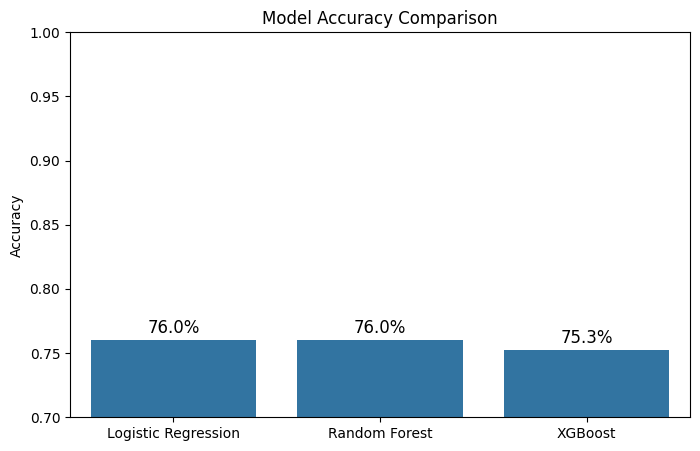

In [ ]:
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
scores = [lr_score, rf_score, xgb_score]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=scores)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0)
for i, score in enumerate(scores):
    plt.text(i, score + 0.005,
             f'{round(score*100, 1)}%',
             ha='center', fontsize=12)
plt.show()

## Model Results
- Logistic Regression: 76.0% accuracy
- Random Forest: 76.0% accuracy  
- XGBoost: 75.3% accuracy

All models performed similarly. Random Forest
selected as best model for evaluation.

Classification Report - Random Forest
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1033
           1       0.55      0.56      0.55       374

    accuracy                           0.76      1407
   macro avg       0.69      0.70      0.69      1407
weighted avg       0.76      0.76      0.76      1407



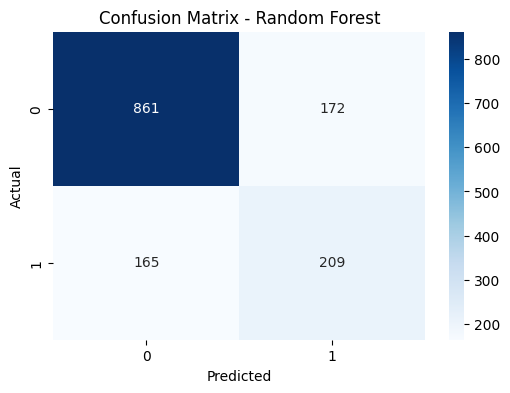

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report - Random Forest")
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Model Evaluation
- Overall accuracy: 76%
- Correctly identified 209 churning customers
- Missed 165 churning customers (false negatives)
- Recall for churn class: 56%

The model misses 44% of churning customers.
Improving recall should be the priority for
future iterations.

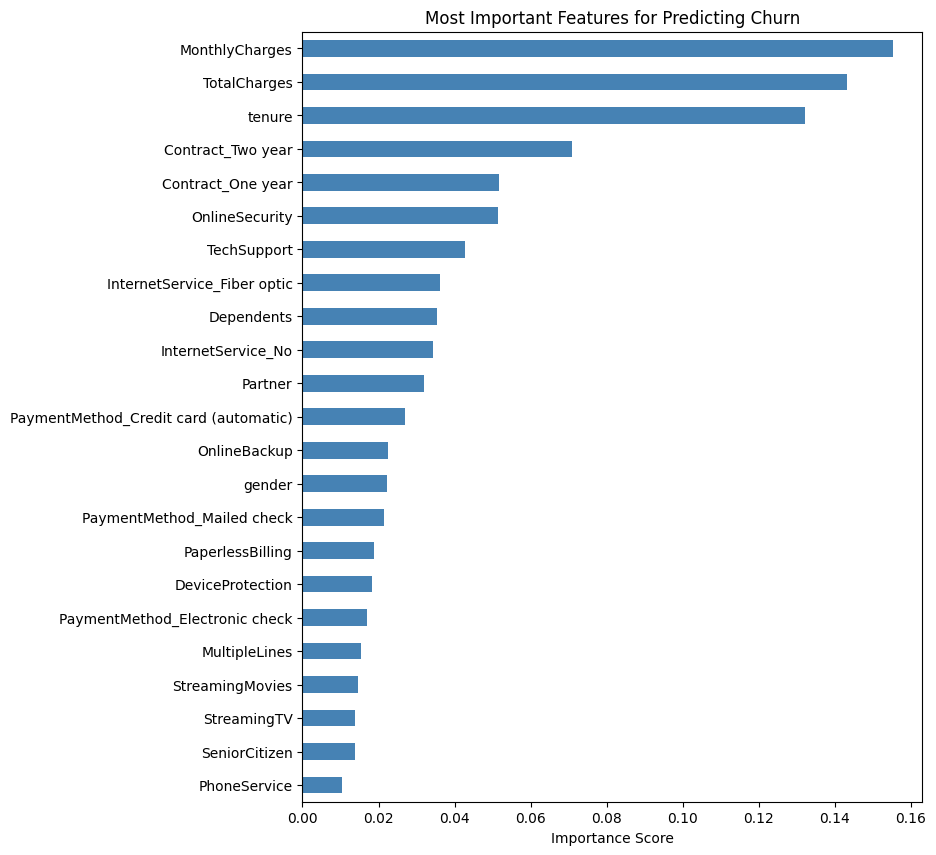

In [ ]:
feat_imp = pd.Series(rf.feature_importances_,
                     index=X.columns)
feat_imp.sort_values().plot(kind='barh',
                            color='steelblue',
                            figsize=(8,10))
plt.title('Most Important Features for Predicting Churn')
plt.xlabel('Importance Score')
plt.show()

## Feature Importance & Business Recommendations
Top predictors of churn:
1. MonthlyCharges — high bills = more likely to leave
2. TotalCharges — related to tenure
3. Tenure — new customers leave more
4. Contract type — month-to-month highest risk

## Recommendations to the company:
1. Offer discounts to new customers in first 3 months
2. Encourage month-to-month customers to upgrade
   to yearly contracts
3. Review fiber optic pricing — too expensive
4. Create loyalty rewards for customers over 2 years